In [1]:
import pickle
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import math
import cleanedup as cu

In [2]:
time_frame = pickle.load(open("Data/time.pickle","rb"))
time_frame = time_frame - int(time_frame[0])

wb_fluxes = pickle.load(open("Data/wb_fluxes.pickle","rb"))

WL_flux = pickle.load(open('Data/WL_flux.pickle', 'rb'))

wl, width, u1, u2 = np.loadtxt('Data/LD_coefficients.dat', unpack=True, usecols=(0,1,2,4))

wb_fluxes.shape, u1.shape, u2.shape, time_frame.shape

((147, 19500), (147,), (147,), (19500,))

In [ ]:
data = np.column_stack((u1, u2, wb_fluxes))
rpIngress, rpEgress = np.zeros(shape = wl.shape), np.zeros(shape = wl.shape)
for n, data in enumerate(data):
    u = data[0:2]
    flux = data[2:]

    tp = cu.TransitParams()
    
    rpIngress[n], rpEgress[n] = cu.main(time_frame, flux, tp = tp, u = u, ephase = 0.06733668341708543, iphase = 0.06733668341708543)      

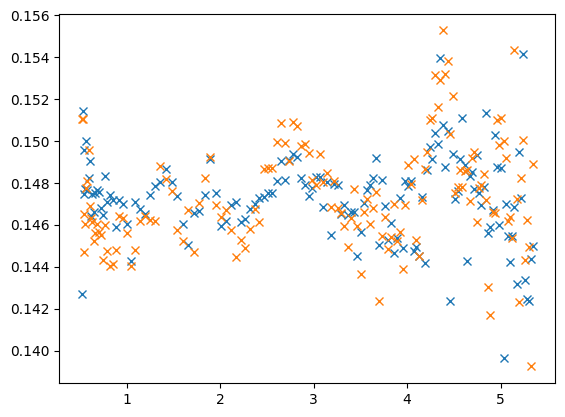

In [6]:
plt.plot(wl, rpEgress, 'x')
plt.plot(wl, rpIngress, 'x')